In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sklearn
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder

from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import SMOTENC
from sklearn.decomposition import PCA
from imblearn.pipeline import Pipeline
from sklearn.metrics import recall_score
from sklearn.metrics import make_scorer
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer, MinMaxScaler
from sklearn.base import BaseEstimator, TransformerMixin

In [2]:
df = pd.read_csv('/Users/Tudor.Orosz/Documents/School/Thesis/Extract Data Athena/dataset_marketing2.csv')

df = df.drop(["id", "accountid", "account_sales_unit__c", "sales_unit_group__c", "name", "createddate"], axis = 1)

## Categorical

In [7]:
import pandas as pd

# Assuming your DataFrame is named 'df'

# Get the first 10 columns of the DataFrame
first_10_cols = df.iloc[:, :54]

# Iterate over each column
for col in df.columns:
    # Get the unique values in the column
    unique_values = df[col].unique()

    # Display the unique values
    print(f'Unique values for {col}:')
    print(unique_values)
    print('\n')

Unique values for gtm_segment__c:
['MFI' 'MXD' 'CH']


Unique values for gtm_industry__c:
['Automotive and Transportation' 'Semiconductor' 'Business Services'
 'Industrial Machinery and Heavy Equipment' 'Government'
 'Banking, Financial & Credit Institution' 'Software & IT'
 'Infrastructure & Construction' 'Education' 'Aerospace and Defense'
 'Electronics' 'Retail' 'Services' 'Insurance'
 'Consumer Products and Retail' 'Utility Service Providers' 'Real Estate'
 'Healthcare' 'Medical Device and Pharmaceutical'
 'Logistics & Transportation' 'Energy and Utilities' 'Other' 'Marine'
 'Gov Defense Agencies' 'Clearing House Review']


Unique values for region__c:
['EMEA - Industry' 'US - Industry' 'US - Diversified' 'EMEA - REV'
 'EMEA - PUBLIC' 'US - Banking' 'APAC - SEA' 'APAC - ANZ' 'EMEA - FSI'
 'APAC - India' 'US - Insurance' 'APAC - Japan' 'APAC - G. China'
 'APAC - South Korea' 'US - Other' 'EMEA - Other']


Unique values for country_grouping__c:
['UKI' 'US' 'Benelux' 'Middle East' 'SE

In [4]:
df

,gtm_segment__c,gtm_industry__c,region__c,country_grouping__c,opportunityid,Fill Out Form_Filled Out Form,WBN_Attended,TS_Attended,TS_Visited Booth,Mendix World Session - Attended_Attended,...,TS_Demo Attendee,Other_Added,Other_Unsubscribed,Other_Logged In,TS_Meeting Attendee,Other_Qualified,TS_Filled Out Form,Other_Visited Web Page,Other_Visited booth,CS_Downloaded Asset
0,MFI,Automotive and Transportation,EMEA - Industry,UKI,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,MFI,Semiconductor,US - Industry,US,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,MXD,Business Services,US - Diversified,US,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,MXD,Business Services,EMEA - REV,Benelux,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,MFI,Industrial Machinery and Heavy Equipment,EMEA - REV,Middle East,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78515,MXD,Insurance,US - Insurance,US,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
78516,MXD,Business Services,US - Diversified,US,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
78517,MXD,Business Services,US - Diversified,US,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
78518,MXD,Business Services,EMEA - REV,Middle East,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Numerical

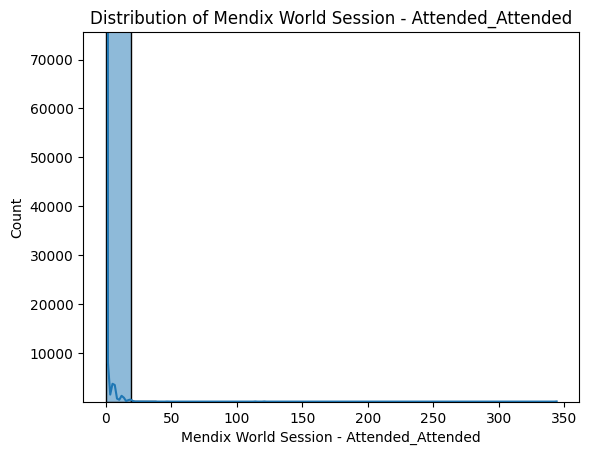

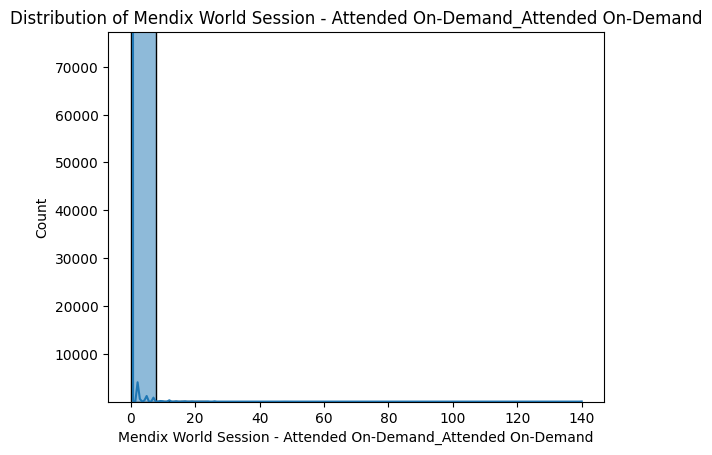

In [5]:
# Assuming your DataFrame is named 'df'

# Select the columns of interest
columns_of_interest = ['Mendix World Session - Attended_Attended',
                       'Mendix World Session - Attended On-Demand_Attended On-Demand']

# Create a subset DataFrame with the selected columns
subset_df = df[columns_of_interest]

# Iterate over the columns
for col in subset_df.columns:
    # Plot the distribution using a histogram
    ax = sns.histplot(subset_df[col], kde=True)
    ax.set_ylim(1, subset_df[col].value_counts().max())
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.title(f'Distribution of {col}')
    plt.show()


In [4]:
unique_values = df['Mendix World Session - Attended_Attended'].unique()

# Display the unique values
print(unique_values)

[  0   4  13   6  10   2   1  11  12   7   5   3   9  17  14 114   8  15
  19  20  16  33  18  22  24  26  25 121  84  23  21 108  49  29  31 344
  48 104 138  58  94  27  37  28  30  47  32]


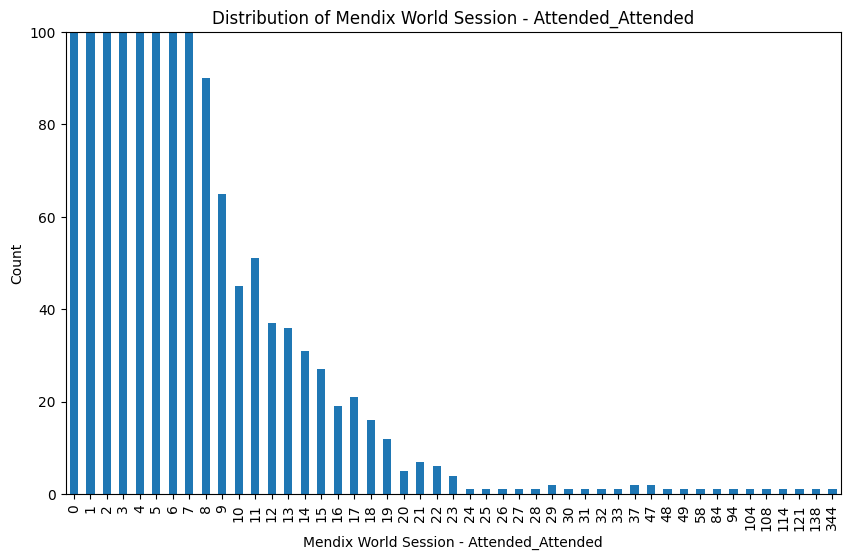

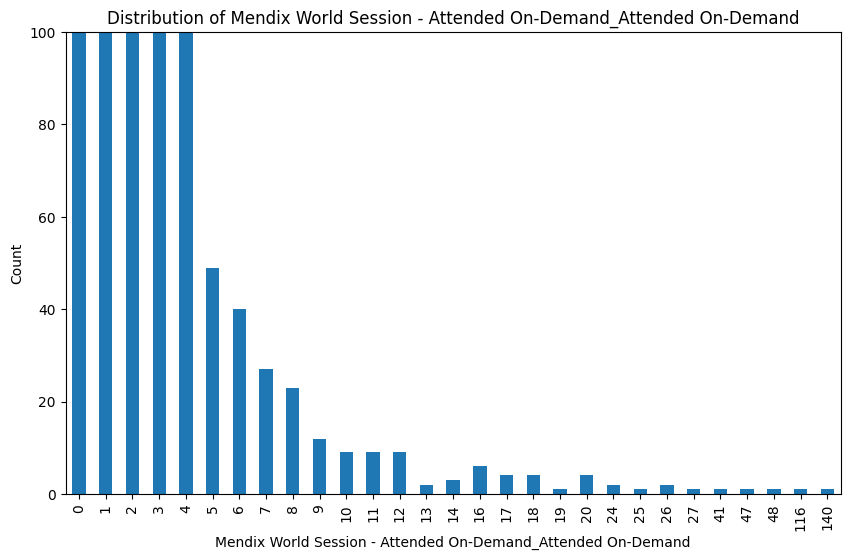

In [8]:
# Select the columns of interest
columns_of_interest = ['Mendix World Session - Attended_Attended',
                       'Mendix World Session - Attended On-Demand_Attended On-Demand']

# Create a subset DataFrame with the selected columns
subset_df = df[columns_of_interest]

# Iterate over the columns
for col in subset_df.columns:
    # Get the value counts for each unique value and sort by index (ascending order)
    value_counts = subset_df[col].value_counts().sort_index()

    # Plot the bar chart
    plt.figure(figsize=(10, 6))
    value_counts.plot(kind='bar')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.title(f'Distribution of {col}')
    plt.ylim(0, 100)  # Set the y-axis limit to 100
    plt.xticks(rotation=90)
    plt.show()

In [37]:
def get_zero_columns(dataframe):
    zero_columns = []
    for column in dataframe.columns:
        if all(dataframe[column] == 0):
            zero_columns.append(column)
    return zero_columns

# Get columns with only 0's
zero_columns = get_zero_columns(df)

# Print the zero columns
print("Columns with only 0's:", zero_columns)

def remove_zero_columns(dataframe, zero_columns):
    dataframe.drop(zero_columns, axis=1, inplace=True)
    return dataframe
# Remove zero columns
df = remove_zero_columns(df, zero_columns)

Columns with only 0's: ['Other_MQL', 'Other_Responded Negative', 'Other_Downloaded from App Store', 'Other_Deployed an App', 'Other_01-Signed Up', 'TS_Filled Out Form', 'Other_Visited Web Page', 'Other_Visited booth', 'CS_Downloaded Asset']


## 1000

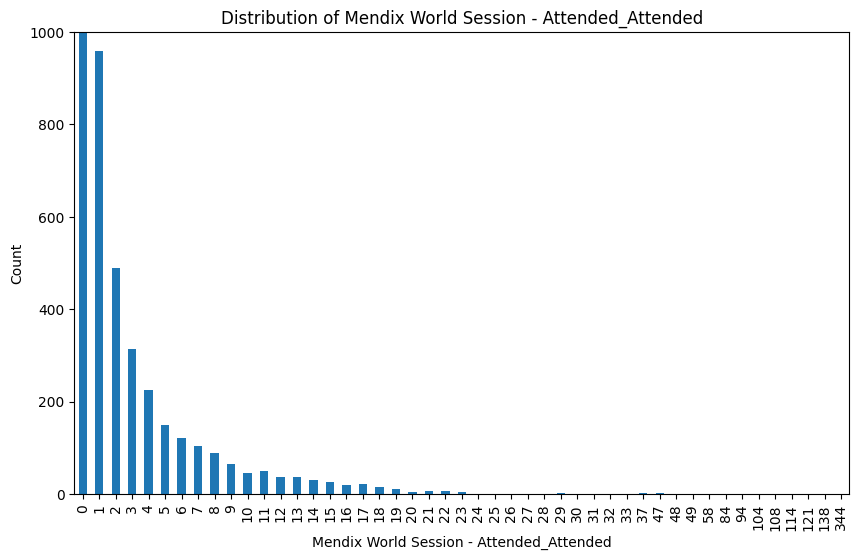

In [15]:
# Select the columns of interest
columns_of_interest = ['Mendix World Session - Attended_Attended']

# Create a subset DataFrame with the selected columns
subset_df = df[columns_of_interest]

# Iterate over the columns
for col in subset_df.columns:
    # Get the value counts for each unique value and sort by index (ascending order)
    value_counts = subset_df[col].value_counts().sort_index()

    # Plot the bar chart
    plt.figure(figsize=(10, 6))
    value_counts.plot(kind='bar')
    plt.xlabel(col)
    plt.ylabel('Count')
    #plt.title(f'Distribution of {col}')
    plt.ylim(0, 1000)  # Set the y-axis limit to 100
    plt.xticks(rotation=90)
    plt.show()

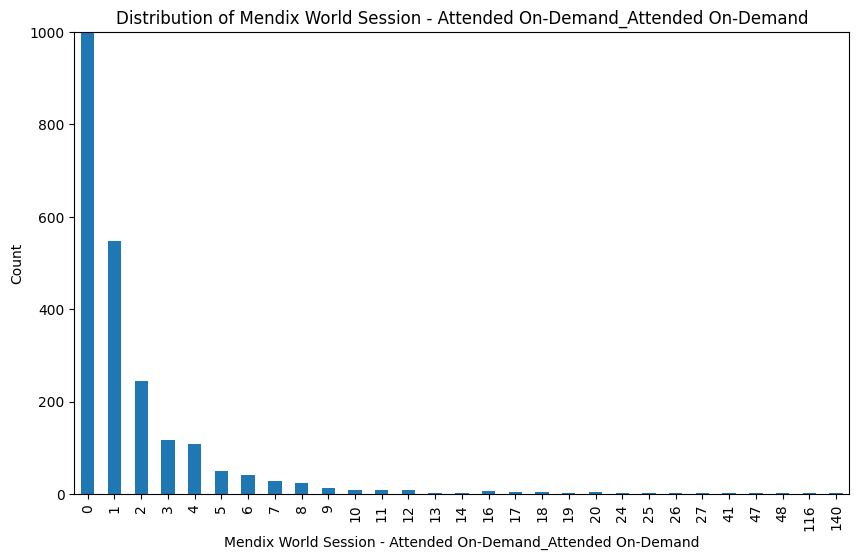

In [16]:
# Select the columns of interest
columns_of_interest = ['Mendix World Session - Attended On-Demand_Attended On-Demand']

# Create a subset DataFrame with the selected columns
subset_df = df[columns_of_interest]

# Iterate over the columns
for col in subset_df.columns:
    # Get the value counts for each unique value and sort by index (ascending order)
    value_counts = subset_df[col].value_counts().sort_index()

    # Plot the bar chart
    plt.figure(figsize=(10, 6))
    value_counts.plot(kind='bar')
    plt.xlabel(col)
    plt.ylabel('Count')
    #plt.title(f'Distribution of {col}')
    plt.ylim(0, 1000)  # Set the y-axis limit to 100
    plt.xticks(rotation=90)
    plt.show()

## 20

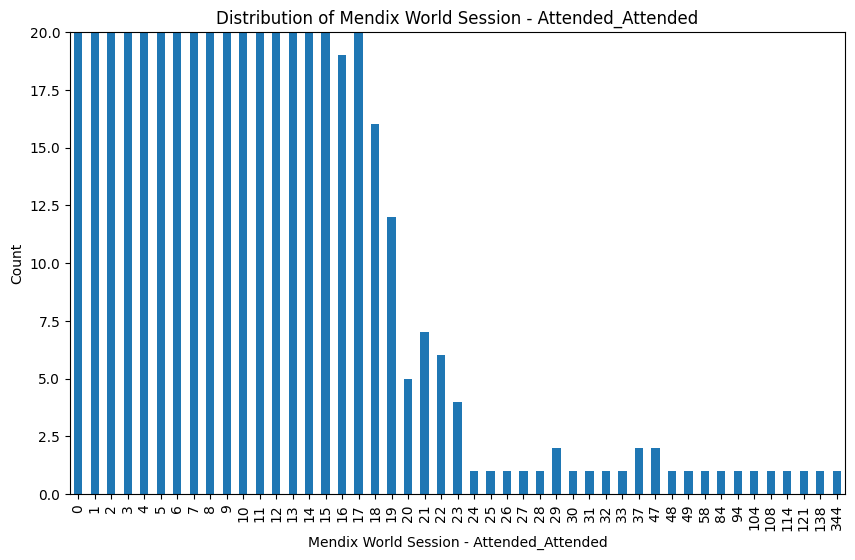

In [17]:
# Select the columns of interest
columns_of_interest = ['Mendix World Session - Attended_Attended']

# Create a subset DataFrame with the selected columns
subset_df = df[columns_of_interest]

# Iterate over the columns
for col in subset_df.columns:
    # Get the value counts for each unique value and sort by index (ascending order)
    value_counts = subset_df[col].value_counts().sort_index()

    # Plot the bar chart
    plt.figure(figsize=(10, 6))
    value_counts.plot(kind='bar')
    plt.xlabel(col)
    plt.ylabel('Count')
    #plt.title(f'Distribution of {col}')
    plt.ylim(0, 20)  # Set the y-axis limit to 100d
    plt.xticks(rotation=90)
    plt.show()

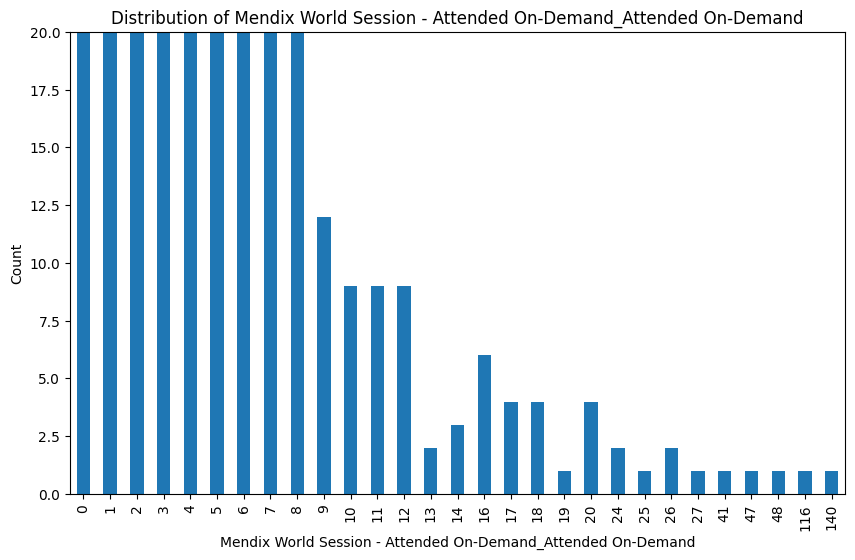

In [18]:
# Select the columns of interest
columns_of_interest = ['Mendix World Session - Attended On-Demand_Attended On-Demand']

# Create a subset DataFrame with the selected columns
subset_df = df[columns_of_interest]

# Iterate over the columns
for col in subset_df.columns:
    # Get the value counts for each unique value and sort by index (ascending order)
    value_counts = subset_df[col].value_counts().sort_index()

    # Plot the bar chart
    plt.figure(figsize=(10, 6))
    value_counts.plot(kind='bar')
    plt.xlabel(col)
    plt.ylabel('Count')
    #plt.title(f'Distribution of {col}')
    plt.ylim(0, 20)  # Set the y-axis limit to 100
    plt.xticks(rotation=90)
    plt.show()